In [33]:
# following https://learn.astropy.org/tutorials/FITS-tables.html
# using output file from https://heasarc.gsfc.nasa.gov/docs/nicer/analysis_threads/bary_corr_phase_resolved_spectra/
# 4 June 2025
# Jacob Payne
# University of Iowa

import os
import sys
import numpy as np
from astropy.io import fits
from astropy.table import Table, vstack
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from math import sqrt

def get_evt_data(obsid, post_fix='_barycorr_PHASE'):
    """
    Get the event data for a given observation ID.
    """
    event_filename = f'/Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/{obsid}/xti/event_cl/ni{obsid}_0mpu7_cl{post_fix}.evt'
    hdu_list = fits.open(event_filename, memmap=True)
    evt_data = Table(hdu_list[1].data)

    # # Print information about the EVT file
    # hdu_list.info()
    # print(hdu_list[1].columns)
    # evt_data #print the Table 
    return evt_data

def write_barycorr_sh(obsids,  target_pulsar):
    """
    Generates a shell script for processing NICER pulsar data.

    Args:
        obsid (str): The NICER observation ID.
        target_pulsar (str): The name of the target pulsar (e.g., "B0531+21").
    """
    from pulsar_dictionary import pulsar_coords

    if target_pulsar not in pulsar_coords:
        print(f"Error: Pulsar '{target_pulsar}' not found in the predefined list.", file=sys.stderr)
        sys.exit(1)
    pulsar_info = pulsar_coords[target_pulsar]
    right_ascension = pulsar_info["ra"]
    declination = pulsar_info["dec"]
    f_0 = pulsar_info["frequency"]
    f_dot = pulsar_info["f_dot"]
    f_epoch = pulsar_info["frequency_epoch"]

    obsroot = '/Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/'

    for obsid in obsids:
        # get the observation time from the evt file
        observation_nicertime = get_evt_data(obsid, post_fix='')[0][0]

        # project f to the epoch of the observation
        print(f"Frequency correction for {obsid}: {f_0} Hz at epoch {f_epoch}")
        f = f_0 + f_dot * (observation_nicertime - f_epoch)
        print(f"Updated to: {f} Hz at epoch {observation_nicertime}")


        #make a new shell script file
        script_content = f"""#!/bin/bash
        # This script was generated by a Python script.
        # It automates the processing of NICER pulsar data,
        # including barycenter correction and phase calculation.

        # --- Script Execution ---

        echo "Starting NICER data processing for observation ID: {obsid}, pulsar: {target_pulsar}"

        # Step 1: Change to the observation root directory
        echo "Changing directory to {obsroot}"
        cd "{obsroot}" || {{ echo "Error: Could not change to obsroot. Exiting."; exit 1; }}

        # Step 2: Run nicerl2
        # echo "Running nicerl2 for obsid {obsid}..."
        # nicerl2 {obsid} clobber=YES || {{ echo "Error: nicerl2 failed. Exiting."; exit 1; }}

        # Step 3: Change to the event_cl directory
        echo "Changing directory to ./{obsid}/xti/event_cl/"
        cd ./{obsid}/xti/event_cl/ || {{ echo "Error: Could not change to ./{obsid}/xti/event_cl/. Exiting."; exit 1; }}

        # Step 4: Perform barycenter correction
        if [ -f "ni{obsid}_0mpu7_cl_barycorr.evt" ]; then
            echo "Removing existing outfile: ni{obsid}_0mpu7_cl_barycorr.evt..."
            rm ni{obsid}_0mpu7_cl_barycorr.evt
        fi

        echo "\n Writing barycenter correction along the LoS to pulsar {target_pulsar} (RA: {right_ascension}, Dec: {declination})"
        barycorr infile=ni{obsid}_0mpu7_cl.evt \\
                outfile=ni{obsid}_0mpu7_cl_barycorr.evt \\
                orbitfiles=../../auxil/ni{obsid}.orb \\
                ra={right_ascension} \\
                dec={declination} \\
                barytime=yes || {{ echo "Error: barycorr failed. Exiting."; exit 1; }}

        # Step 5: Create BARY_REF_TIME based on the barycenter and reference ephemeris time
        # formerly calculated BARYTIME-f_epoch
        # call a python script to read the minimum BARYTIME from the evt file
        REFTIME=$(python ../../../../hpy/read_barytime.py {obsid})
        echo "\n Calculating BARY_REF_TIME"
        EXP_STR="(BARYTIME-$REFTIME)"
        ftcalc infile='ni{obsid}_0mpu7_cl_barycorr.evt[events]' \\
            outfile=ni{obsid}_0mpu7_cl_barycorr.evt \\
            column=BARY_REF_TIME \\
            expression=$EXP_STR \\
            clobber=yes || {{ echo "Error: ftcalc for BARY_REF_TIME failed. Exiting."; exit 1; }}

        # Step 6: Calculate PHASE
        if [ -f "ni{obsid}_0mpu7_cl_barycorr_PHASE.evt" ]; then
            echo "Removing existing outfile: ni{obsid}_0mpu7_cl_barycorr_PHASE.evt..."
            rm "ni{obsid}_0mpu7_cl_barycorr_PHASE.evt"
        fi

        echo "Calculating PHASE using frequency: {f} and f_dot: {f_dot}"
        ftcalc infile='ni{obsid}_0mpu7_cl_barycorr.evt[events]' \\
            outfile=ni{obsid}_0mpu7_cl_barycorr_PHASE.evt \\
            column=PHASE \\
            expression='({f}*(BARY_REF_TIME)+({f_dot}*(BARY_REF_TIME**2)/2))%1' \\
            clobber=yes || {{ echo "Error: ftcalc for PHASE failed. Exiting."; exit 1; }}

        echo "Script finished successfully for {target_pulsar} (ObsID: {obsid})."
        """
        script_filename = f'{obsroot}process_nicer_{obsid}.sh'
        with open(script_filename, 'w') as script_file:
            script_file.write(script_content)
        print(f'Shell script written to {script_filename}')
        os.chmod(script_filename, 0o755)  # Make the script executable


    return

def combine_phaseograms(obsids):
    # Combine multiple obsids into a single phase-o-gram (the pulse profile)
    combined_counts = np.zeros(100)
    for obsid in obsids:
        evt_data = get_evt_data(obsid, post_fix='_barycorr_PHASE')
        phase_o_gram = np.histogram(evt_data['PHASE'], bins=100)[0]
        combined_counts = np.add(combined_counts,phase_o_gram)
    return combined_counts

def combine_phase_energy(obsids):
    ## Combine multiple obsids into one evt table

    #create an empty astropy table to hold the combined data
    combined_evt_data = Table()
    for obsid in obsids:
        event_filename = f'/Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/{obsid}/xti/event_cl/ni{obsid}_0mpu7_cl_barycorr_PHASE.evt'
        hdu_list = fits.open(event_filename, memmap=True)
        evt_data = Table(hdu_list[1].data)
        #combine astropy tables
        if combined_evt_data:
            combined_evt_data = vstack([combined_evt_data, evt_data])
        else:
            combined_evt_data = evt_data
    
    print(f'Combined {len(obsids)} obsids into one evt table with {len(combined_evt_data)} events')
    
    return combined_evt_data


In [56]:
# attempt to parse new data files

# write_barycorr_sh(['1070020409','1070020411','3070020581','1070020415','5070020753', '6070020833'], target_pulsar='B1937+21')
write_barycorr_sh(['3013010102'], target_pulsar='B0531+21')

Frequency correction for 3013010102: 29.6095750017 Hz at epoch 195177602.025552
Updated to: 29.609309114134707 Hz at epoch 195899780.00023863
Shell script written to /Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/process_nicer_3013010102.sh


In [57]:
"""
| Observation ID | Remarks             |
| -------------- | ------------------- |
| 3013010102     | Crab                |
| 3070020581     | Peak at Phase ~ 0.5 |
| 1070020409     | Noise               |
| 1070020411     | Noise               |
| 5070020753     | Peak!               |
| 6070020833     | Peak?               |
| 1070020415     | Noise (negative Phase fixed by referencing minimum barytime)   |
"""

obsid_list = ['3013010102']
multi_phase_o_gram = combine_phaseograms(obsid_list)
evt_data = get_evt_data(obsid_list[0])

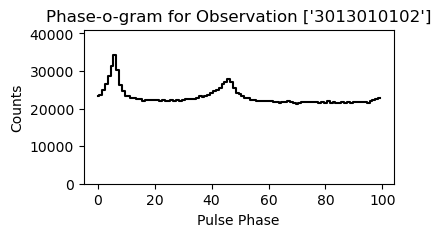

In [58]:
## Plot the combined pulse profile
def plot_phaseogram(phase_o_gram, obsids):
    plt.figure(figsize=(4, 2))
    plt.plot(phase_o_gram, drawstyle='steps-mid', color='black')
    plt.ylim(0, 1.2 * max(multi_phase_o_gram))
    plt.xlabel('Pulse Phase')
    plt.ylabel('Counts')
    plt.title(f'Phase-o-gram for Observation {obsids}')
    plt.show()

plot_phaseogram(multi_phase_o_gram, obsid_list)

In [18]:
#use astropy to read the first and minimum of the time and bary_ref_time values
def print_evt_time_info(evt_data):
    """
    Print the first and minimum values of TIME and BARY_REF_TIME from the event data.
    """
    print(f"First TIME: {evt_data['TIME'][0]}")
    print(f"Minimum TIME: {np.min(evt_data['TIME'])}")
    print(f"First BARYTIME: {evt_data['BARYTIME'][0]}")
    print(f"Minimum BARYTIME: {np.min(evt_data['BARYTIME'])}")
    print(f"\n BARYTIME - TIME = {evt_data['BARYTIME'][0] - evt_data['TIME'][0]}")
    print(f"First BARY_REF_TIME: {evt_data['BARY_REF_TIME'][0]}")
    print(f"Minimum BARY_REF_TIME: {np.min(evt_data['BARY_REF_TIME'])}")
evt_data = get_evt_data(obsid_list[0])
print_evt_time_info(evt_data)


First TIME: 156474027.05097538
Minimum TIME: 156474027.05097538
First BARYTIME: 156473734.2873806
Minimum BARYTIME: 156473734.2873806

 BARYTIME - TIME = -292.763594776392
First BARY_REF_TIME: -292.763594776392
Minimum BARY_REF_TIME: -292.763594776392


Combined 1 obsids into one evt table with 43811 events
Found 43807 unique phases from -0.9993913107464323 to 0.9998919116333127 in the combined data.
Scaling to 32 phase bins.
Found 1409 unique PI channels from 20 to 1500 in the combined data.
Scaling to 250 energy bins.


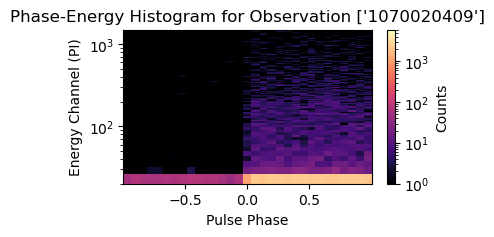

In [8]:
# Plot a 2D phase-o-gram of counts in each phase bin along the x-axis and energy bin along the y-axis
# for multiple obsids
combo_evt = combine_phase_energy(obsid_list)

def phase_energy_histogram(evt_data, obsids):
    """
    Plot a 2D histogram of phase vs energy.
    """
    #get bins from the evt_data astropy table
    phases = np.unique(evt_data['PHASE'])
    print(f'Found {len(phases)} unique phases from {min(phases)} to {max(phases)} in the combined data.')
    
    pbins = 32
    if len(phases) > pbins:
        print(f'Scaling to {pbins} phase bins.')
    phases = np.linspace(min(phases), max(phases), pbins)
    energies = np.unique(evt_data['PI'])
    print(f'Found {len(energies)} unique PI channels from {min(energies)} to {max(energies)} in the combined data.')
   
    ebins = 250
    if len(energies) > ebins:
        print(f'Scaling to {ebins} energy bins.')
    energies = np.linspace(min(energies), max(energies), ebins)
    
    #bins = (#phase, #energy)
    set_bins = (phases, energies)

    plt.figure(figsize=(4, 2))
    plt.hist2d(evt_data['PHASE'], evt_data['PI'], bins=set_bins, norm=LogNorm(vmin=1, vmax=6000), cmap='magma')
    plt.colorbar(label='Counts')
    plt.gca().set_facecolor('black')  # Set the background to black
    plt.xlabel('Pulse Phase')
    plt.ylabel('Energy Channel (PI)')
    plt.yscale('log')
    plt.title(f'Phase-Energy Histogram for Observation {obsids}')
    plt.show()

combo_evt_hist = phase_energy_histogram(combo_evt, obsid_list)


In [ ]:
# filter a pass-band of interest
def filter_passband(hist_input, low_energy=0, high_energy=100):
    """
    Filter the event data for a specific energy range.
    """
    filtered_data = hist_input[(hist_input['PI'] >= low_energy) & (hist_input['PI'] <= high_energy)]
    return filtered_data

phase_energy_histogram(filter_passband(combo_evt, low_energy=25, high_energy=300), obsid_list)


In [ ]:
# TODO: SNR window, using SNR = (s-b)/sqrt(b)
# b = 
# b from Poisson Error, look for Gehrel's error

# filter out energy channels with low signal-to-noise ratio
def filter_low_snr(evt_data):
    """
    Filter out energy channels with low signal-to-noise ratio.
    """
    # Calculate the mean and standard deviation of counts in each energy channel
    snr_table = Table()
    filtered_evt_data = Table()
    for channel in np.unique(evt_data['PI']):
        channel_data = evt_data[evt_data['PI'] == channel]
        if len(channel_data) > 0:
            mean_counts = np.mean(channel_data['PHASE']) # TODO: check the table
            plt.plot(channel_data['PHASE'], label=f'Channel {channel}', drawstyle='steps-mid')
            plt.xlabel('Pulse Phase')
            std_counts = np.std(channel_data['PHASE'])
            if std_counts == 0:
                snr = 0
            else:
                snr = mean_counts / std_counts
            snr_table[evt_data['PI'] == channel] = snr
            if snr > 1.77:
                if filtered_evt_data:
                    filtered_evt_data = vstack([filtered_evt_data, channel_data])
                else:
                    filtered_evt_data = channel_data
        else:
            snr_table[evt_data['PI'] == channel] = 0
        print(f"Channel: {channel}, Mean Counts: {mean_counts}, Std Counts: {std_counts}, SNR: {snr}")
    return filtered_evt_data

filtered_evt = filter_low_snr(combo_evt)
phase_energy_histogram(filtered_evt, obsid_list)

# plot the pulse profile for the filtered data
plot_phaseogram(np.histogram(filtered_evt['PHASE'], bins=100)[0], obsid_list)


In [ ]:
# Calculate and plot signal statistics for each energy bin

phase_pi_hist = np.histogram2d(combo_evt['PHASE'], combo_evt['PI'], bins=(100, 200))[0]
# Calculate the signal statistic for each energy bin
# Signal statistic = (max - min) / sqrt(avg)
# where max, min, and avg are the maximum, minimum, and average counts in each energy bin across all phase bins

max_values = np.max(phase_pi_hist, axis=1)
min_values = np.min(phase_pi_hist, axis=1)
avg_values = np.mean(phase_pi_hist, axis=1)
signal_statistic = (max_values-min_values) / np.sqrt(avg_values)

plt.figure(figsize=(4, 2))
plt.plot(signal_statistic, drawstyle='steps-mid', color='black')
plt.xlabel('Energy Channel (PI)')
plt.ylabel('Signal Statistic')
plt.title(f'Signal Statistic for Observations {obsid_list}')

#plot the phase histogram for the energy bin with the highest signal statistic
max_signal_index = np.argmax(signal_statistic)
max_signal_phase_hist = np.histogram(combo_evt['PHASE'][combo_evt['PI'] == max_signal_index], bins=100)[0]
plt.figure(figsize=(4, 2))
plt.plot(max_signal_phase_hist, drawstyle='steps-mid', color='black')
plt.xlabel('Pulse Phase')
plt.ylabel('Counts')
plt.title(f'Phase Histogram for Energy Channel {max_signal_index} with Highest Signal Statistic')

